In [3]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
from concurrent.futures import ThreadPoolExecutor
from torch.cuda.amp import GradScaler, autocast

# Function to load individual CSV files
def load_data(file_path):
    try:
        df = pd.read_csv(file_path, delimiter=';\t', engine='python', header=None, skiprows=1)
        df.columns = ['Timestamp', 'CPU Cores', 'CPU Capacity Provisioned', 'CPU Usage MHz', 'CPU Usage %',
                      'Memory Provisioned KB', 'Memory Usage KB', 'Disk Read KB/s', 'Disk Write KB/s',
                      'Network Received KB/s', 'Network Transmitted KB/s']
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='ms', errors='coerce')
        df.set_index('Timestamp', inplace=True)
        return df
    except Exception as e:
        print(f"Error loading file {file_path}: {e}")
        return None

# Function to load all CSV data from a directory using parallel processing
def load_all_data(directory):
    all_files = glob.glob(os.path.join(directory, "*.csv"))
    if not all_files:
        raise ValueError(f"No CSV files found in directory: {directory}")
    
    with ThreadPoolExecutor() as executor:
        data_list = list(executor.map(load_data, all_files))
    
    data_list = [df for df in data_list if df is not None]
    return pd.concat(data_list, axis=0) if data_list else None

# Data preparation function
def prepare_data(df, feature_columns, target_column, time_steps=20):
    scaler = MinMaxScaler()
    df_scaled = scaler.fit_transform(df[feature_columns + [target_column]])

    X, y = [], []
    for i in range(len(df_scaled) - time_steps):
        X.append(df_scaled[i:i+time_steps, :-1])
        y.append(df_scaled[i+time_steps, -1])

    X = torch.FloatTensor(np.array(X))
    y = torch.FloatTensor(np.array(y)).unsqueeze(-1)
    return X, y, scaler

# LSTM model class for PyTorch
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size1=100, hidden_size2=100, hidden_size3=50, dropout_rate=0.3):
        super(LSTMModel, self).__init__()
        self.lstm1 = nn.LSTM(input_size, hidden_size1, batch_first=True)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.lstm2 = nn.LSTM(hidden_size1, hidden_size2, batch_first=True)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.lstm3 = nn.LSTM(hidden_size2, hidden_size3, batch_first=True)
        self.dropout3 = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(hidden_size3, 50)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(50, 25)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(25, 1)

    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.dropout1(x)
        x, _ = self.lstm2(x)
        x = self.dropout2(x)
        x, _ = self.lstm3(x)
        x = self.dropout3(x)
        x = self.fc1(x[:, -1, :])  # Take the last time step
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

# Function to save checkpoint
def save_checkpoint(model, optimizer, epoch, loss, checkpoint_path='checkpoint.pth'):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }, checkpoint_path)
    print(f"Checkpoint saved at epoch {epoch}")

# Function to load checkpoint
def load_checkpoint(model, optimizer, checkpoint_path='checkpoint.pth'):
    if os.path.isfile(checkpoint_path):
        checkpoint = torch.load(checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1  # Resume from next epoch
        loss = checkpoint['loss']
        print(f"Checkpoint loaded, resuming from epoch {start_epoch}")
        return start_epoch, loss
    else:
        print("No checkpoint found, starting from scratch")
        return 0, None

# Main execution
def main():
    data_directory = "./fastStorage/2013-8"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    checkpoint_path = 'checkpoint.pth'
    
    # Check if directory exists
    if not os.path.exists(data_directory):
        print(f"Directory not found: {data_directory}")
        return
    
    print("Loading data...")
    df = load_all_data(data_directory)
    
    if df is None or df.empty:
        print("No valid data found. Exiting.")
        return
    
    print("Data loaded successfully. Preparing dataset...")
    
    feature_columns = ['CPU Cores', 'CPU Capacity Provisioned', 'CPU Usage MHz', 'Memory Provisioned KB',
                       'Memory Usage KB', 'Disk Read KB/s', 'Disk Write KB/s', 'Network Received KB/s',
                       'Network Transmitted KB/s']
    target_column = 'CPU Usage %'

    X, y, scaler = prepare_data(df, feature_columns, target_column)
    
    # Split data
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    print(f"Training data: {X_train.shape}, Testing data: {X_test.shape}")

    # Create DataLoader for training and testing
    batch_size = 512  # Increased for better GPU utilization
    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)

    # Initialize model
    model = LSTMModel(input_size=X_train.shape[2]).to(device)
    optimizer = optim.Adam(model.parameters())
    criterion = nn.MSELoss()
    scaler = GradScaler()  # For mixed precision training

    # Load checkpoint if exists
    start_epoch, _ = load_checkpoint(model, optimizer, checkpoint_path)
    
    print("Training LSTM model...")
    num_epochs = 50
    
    try:
        for epoch in range(start_epoch, num_epochs):
            model.train()
            total_loss = 0
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                optimizer.zero_grad()
                with autocast():  # Mixed precision context
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                scaler.scale(loss).backward()  # Scale loss for mixed precision
                scaler.step(optimizer)         # Update weights
                scaler.update()                # Update scaler
                total_loss += loss.item()
            
            avg_train_loss = total_loss / len(train_loader)
            
            # Validation
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for batch_X, batch_y in test_loader:
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    with autocast():  # Optional for validation
                        val_outputs = model(batch_X)
                        val_loss += criterion(val_outputs, batch_y).item()
            
            avg_val_loss = val_loss / len(test_loader)
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
            
            # Save checkpoint after each epoch
            save_checkpoint(model, optimizer, epoch, avg_train_loss, checkpoint_path)
    
    except KeyboardInterrupt:
        print("Training interrupted. Saving checkpoint...")
        save_checkpoint(model, optimizer, epoch, avg_train_loss, checkpoint_path)
        print("Checkpoint saved. Exiting.")

    # Predictions
    model.eval()
    with torch.no_grad():
        predictions = []
        for batch_X, _ in test_loader:
            batch_X = batch_X.to(device)
            with autocast():
                batch_pred = model(batch_X)
            predictions.append(batch_pred.cpu())
        predictions = torch.cat(predictions, dim=0)
    
    print("Model training complete. Predictions generated.")
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Function to inverse transform predictions and actual values
def inverse_transform_predictions(predictions, actuals, scaler, target_idx):
    # Create dummy arrays with the same number of features as the scaler expects
    dummy = np.zeros((len(predictions), scaler.n_features_in_))
    dummy[:, target_idx] = predictions.flatten()  # Fill target column with predictions
    pred_original = scaler.inverse_transform(dummy)[:, target_idx]
    
    dummy[:, target_idx] = actuals.flatten()  # Fill target column with actuals
    actual_original = scaler.inverse_transform(dummy)[:, target_idx]
    
    return pred_original, actual_original

# Evaluation and visualization function
def evaluate_and_visualize(model, test_loader, y_test, scaler, feature_columns, target_column, device):
    model.eval()
    predictions = []
    actuals = y_test.cpu().numpy()  # Convert actuals to numpy

    # Generate predictions
    with torch.no_grad():
        for batch_X, _ in test_loader:
            batch_X = batch_X.to(device)
            with autocast():
                batch_pred = model(batch_X)
            predictions.append(batch_pred.cpu())
    predictions = torch.cat(predictions, dim=0).numpy()

    # Get the index of the target column in the original feature set
    target_idx = len(feature_columns)  # Since target_column is appended last in prepare_data

    # Inverse transform to original scale
    pred_original, actual_original = inverse_transform_predictions(predictions, actuals, scaler, target_idx)

    # Calculate evaluation metrics
    mse = mean_squared_error(actual_original, pred_original)
    mae = mean_absolute_error(actual_original, pred_original)
    r2 = r2_score(actual_original, pred_original)

    print("\nEvaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")

    # Visualization: Plot actual vs predicted
    plt.figure(figsize=(12, 6))
    plt.plot(actual_original, label="Actual CPU Usage %", color="blue", alpha=0.6)
    plt.plot(pred_original, label="Predicted CPU Usage %", color="red", alpha=0.6)
    plt.title("Actual vs Predicted CPU Usage %")
    plt.xlabel("Time Step")
    plt.ylabel("CPU Usage %")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Optional: Scatter plot for correlation
    plt.figure(figsize=(6, 6))
    plt.scatter(actual_original, pred_original, alpha=0.5)
    plt.plot([min(actual_original), max(actual_original)], [min(actual_original), max(actual_original)], 'r--', lw=2)
    plt.title("Actual vs Predicted (Scatter)")
    plt.xlabel("Actual CPU Usage %")
    plt.ylabel("Predicted CPU Usage %")
    plt.grid(True)
    plt.show()

    # Save predictions to CSV (optional)
    results_df = pd.DataFrame({
        "Actual": actual_original,
        "Predicted": pred_original
    })
    results_df.to_csv("predictions.csv", index=False)
    print("Predictions saved to 'predictions.csv'")

# Update main() to include evaluation and visualization
def main():
    # ... (your existing code until predictions) ...

    print("Model training complete. Predictions generated.")
    
    # Add evaluation and visualization
    print("Evaluating and visualizing results...")
    evaluate_and_visualize(model, test_loader, y_test, scaler, feature_columns, target_column, device)

# Run the script
if __name__ == "__main__":
    main()

# Run the script
if __name__ == "__main__":
    main()

# Check available files and GPU status
print("Files found:", os.listdir("./"))
print("CUDA available:", torch.cuda.is_available())
print("Current device:", torch.cuda.current_device() if torch.cuda.is_available() else "CPU")

Model training complete. Predictions generated.
Evaluating and visualizing results...


NameError: name 'model' is not defined

In [2]:
# Load trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMModel(input_size=X_test.shape[2]).to(device)
optimizer = optim.Adam(model.parameters())

# Load the checkpoint
checkpoint_path = 'checkpoint.pth'
start_epoch, _ = load_checkpoint(model, optimizer, checkpoint_path)

# Set model to evaluation mode
model.eval()


NameError: name 'X_test' is not defined

Loading data...
Data loaded successfully. Preparing dataset...
Training data: torch.Size([8977424, 20, 9]), Testing data: torch.Size([2244356, 20, 9])
Checkpoint loaded, resuming from epoch 50
Training LSTM model...


/tmp/ipykernel_1113216/276566017.py:226: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_grad = GradScaler()  # Renamed to avoid conflict with 'scaler'
/tmp/ipykernel_1113216/276566017.py:278: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Model training complete. Predictions generated.
Evaluating and visualizing results...


/tmp/ipykernel_1113216/276566017.py:130: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Evaluation Metrics:
Mean Squared Error (MSE): 16.0220
Mean Absolute Error (MAE): 2.1374
R² Score: 0.9646


/opt/tljh/user/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


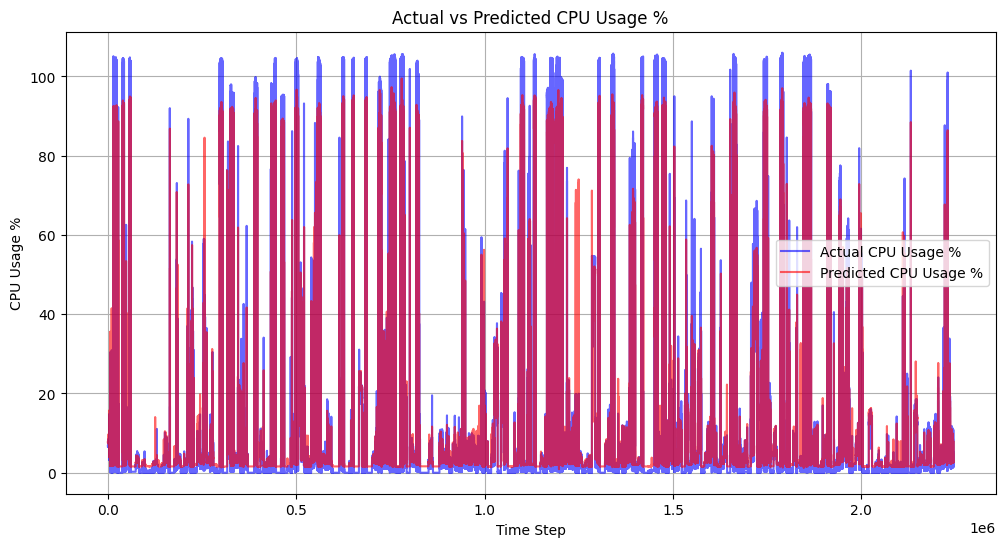

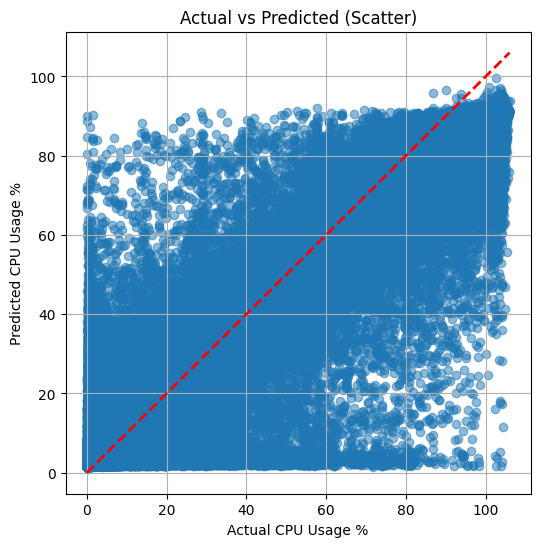

Predictions saved to 'predictions.csv'
Files found: ['main.ipynb', 'Untitled.ipynb', '.ipynb_checkpoints', 'checkpoint.pth', 'fastStorage', 'predictions.csv']
CUDA available: True
Current device: 0


In [4]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
from concurrent.futures import ThreadPoolExecutor
from torch.cuda.amp import GradScaler, autocast
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Function to load individual CSV files
def load_data(file_path):
    try:
        df = pd.read_csv(file_path, delimiter=';\t', engine='python', header=None, skiprows=1)
        df.columns = ['Timestamp', 'CPU Cores', 'CPU Capacity Provisioned', 'CPU Usage MHz', 'CPU Usage %',
                      'Memory Provisioned KB', 'Memory Usage KB', 'Disk Read KB/s', 'Disk Write KB/s',
                      'Network Received KB/s', 'Network Transmitted KB/s']
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='ms', errors='coerce')
        df.set_index('Timestamp', inplace=True)
        return df
    except Exception as e:
        print(f"Error loading file {file_path}: {e}")
        return None

# Function to load all CSV data from a directory using parallel processing
def load_all_data(directory):
    all_files = glob.glob(os.path.join(directory, "*.csv"))
    if not all_files:
        raise ValueError(f"No CSV files found in directory: {directory}")
    
    with ThreadPoolExecutor() as executor:
        data_list = list(executor.map(load_data, all_files))
    
    data_list = [df for df in data_list if df is not None]
    return pd.concat(data_list, axis=0) if data_list else None

# Data preparation function
def prepare_data(df, feature_columns, target_column, time_steps=20):
    scaler = MinMaxScaler()
    df_scaled = scaler.fit_transform(df[feature_columns + [target_column]])

    X, y = [], []
    for i in range(len(df_scaled) - time_steps):
        X.append(df_scaled[i:i+time_steps, :-1])
        y.append(df_scaled[i+time_steps, -1])

    X = torch.FloatTensor(np.array(X))
    y = torch.FloatTensor(np.array(y)).unsqueeze(-1)
    return X, y, scaler

# LSTM model class for PyTorch
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size1=100, hidden_size2=100, hidden_size3=50, dropout_rate=0.3):
        super(LSTMModel, self).__init__()
        self.lstm1 = nn.LSTM(input_size, hidden_size1, batch_first=True)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.lstm2 = nn.LSTM(hidden_size1, hidden_size2, batch_first=True)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.lstm3 = nn.LSTM(hidden_size2, hidden_size3, batch_first=True)
        self.dropout3 = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(hidden_size3, 50)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(50, 25)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(25, 1)

    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.dropout1(x)
        x, _ = self.lstm2(x)
        x = self.dropout2(x)
        x, _ = self.lstm3(x)
        x = self.dropout3(x)
        x = self.fc1(x[:, -1, :])  # Take the last time step
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

# Function to save checkpoint
def save_checkpoint(model, optimizer, epoch, loss, checkpoint_path='checkpoint.pth'):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }, checkpoint_path)
    print(f"Checkpoint saved at epoch {epoch}")

# Function to load checkpoint
def load_checkpoint(model, optimizer, checkpoint_path='checkpoint.pth'):
    if os.path.isfile(checkpoint_path):
        checkpoint = torch.load(checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1  # Resume from next epoch
        loss = checkpoint['loss']
        print(f"Checkpoint loaded, resuming from epoch {start_epoch}")
        return start_epoch, loss
    else:
        print("No checkpoint found, starting from scratch")
        return 0, None

# Function to inverse transform predictions and actual values
def inverse_transform_predictions(predictions, actuals, scaler, target_idx):
    dummy = np.zeros((len(predictions), scaler.n_features_in_))
    dummy[:, target_idx] = predictions.flatten()  # Fill target column with predictions
    pred_original = scaler.inverse_transform(dummy)[:, target_idx]
    
    dummy[:, target_idx] = actuals.flatten()  # Fill target column with actuals
    actual_original = scaler.inverse_transform(dummy)[:, target_idx]
    
    return pred_original, actual_original

# Evaluation and visualization function
def evaluate_and_visualize(model, test_loader, y_test, scaler, feature_columns, target_column, device):
    model.eval()
    predictions = []
    actuals = y_test.cpu().numpy()  # Convert actuals to numpy

    # Generate predictions
    with torch.no_grad():
        for batch_X, _ in test_loader:
            batch_X = batch_X.to(device)
            with autocast():
                batch_pred = model(batch_X)
            predictions.append(batch_pred.cpu())
    predictions = torch.cat(predictions, dim=0).numpy()

    # Get the index of the target column in the original feature set
    target_idx = len(feature_columns)  # Target column is appended last in prepare_data

    # Inverse transform to original scale
    pred_original, actual_original = inverse_transform_predictions(predictions, actuals, scaler, target_idx)

    # Calculate evaluation metrics
    mse = mean_squared_error(actual_original, pred_original)
    mae = mean_absolute_error(actual_original, pred_original)
    r2 = r2_score(actual_original, pred_original)

    print("\nEvaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")

    # Visualization: Plot actual vs predicted
    plt.figure(figsize=(12, 6))
    plt.plot(actual_original, label="Actual CPU Usage %", color="blue", alpha=0.6)
    plt.plot(pred_original, label="Predicted CPU Usage %", color="red", alpha=0.6)
    plt.title("Actual vs Predicted CPU Usage %")
    plt.xlabel("Time Step")
    plt.ylabel("CPU Usage %")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Scatter plot for correlation
    plt.figure(figsize=(6, 6))
    plt.scatter(actual_original, pred_original, alpha=0.5)
    plt.plot([min(actual_original), max(actual_original)], [min(actual_original), max(actual_original)], 'r--', lw=2)
    plt.title("Actual vs Predicted (Scatter)")
    plt.xlabel("Actual CPU Usage %")
    plt.ylabel("Predicted CPU Usage %")
    plt.grid(True)
    plt.show()

    # Save predictions to CSV
    results_df = pd.DataFrame({
        "Actual": actual_original,
        "Predicted": pred_original
    })
    results_df.to_csv("predictions.csv", index=False)
    print("Predictions saved to 'predictions.csv'")

# Main execution
def main():
    data_directory = "./fastStorage/2013-8"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    checkpoint_path = 'checkpoint.pth'
    
    # Check if directory exists
    if not os.path.exists(data_directory):
        print(f"Directory not found: {data_directory}")
        return
    
    print("Loading data...")
    df = load_all_data(data_directory)
    
    if df is None or df.empty:
        print("No valid data found. Exiting.")
        return
    
    print("Data loaded successfully. Preparing dataset...")
    
    feature_columns = ['CPU Cores', 'CPU Capacity Provisioned', 'CPU Usage MHz', 'Memory Provisioned KB',
                       'Memory Usage KB', 'Disk Read KB/s', 'Disk Write KB/s', 'Network Received KB/s',
                       'Network Transmitted KB/s']
    target_column = 'CPU Usage %'

    X, y, scaler = prepare_data(df, feature_columns, target_column)
    
    # Split data
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    print(f"Training data: {X_train.shape}, Testing data: {X_test.shape}")

    # Create DataLoader for training and testing
    batch_size = 512
    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)

    # Initialize model
    model = LSTMModel(input_size=X_train.shape[2]).to(device)
    optimizer = optim.Adam(model.parameters())
    criterion = nn.MSELoss()
    scaler_grad = GradScaler()  # Renamed to avoid conflict with 'scaler'

    # Load checkpoint if exists
    start_epoch, _ = load_checkpoint(model, optimizer, checkpoint_path)
    
    print("Training LSTM model...")
    num_epochs = 50
    
    try:
        for epoch in range(start_epoch, num_epochs):
            model.train()
            total_loss = 0
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                optimizer.zero_grad()
                with autocast():
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                scaler_grad.scale(loss).backward()
                scaler_grad.step(optimizer)
                scaler_grad.update()
                total_loss += loss.item()
            
            avg_train_loss = total_loss / len(train_loader)
            
            # Validation
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for batch_X, batch_y in test_loader:
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    with autocast():
                        val_outputs = model(batch_X)
                        val_loss += criterion(val_outputs, batch_y).item()
            
            avg_val_loss = val_loss / len(test_loader)
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
            
            # Save checkpoint after each epoch
            save_checkpoint(model, optimizer, epoch, avg_train_loss, checkpoint_path)
    
    except KeyboardInterrupt:
        print("Training interrupted. Saving checkpoint...")
        save_checkpoint(model, optimizer, epoch, avg_train_loss, checkpoint_path)
        print("Checkpoint saved. Exiting.")

    # Predictions
    model.eval()
    with torch.no_grad():
        predictions = []
        for batch_X, _ in test_loader:
            batch_X = batch_X.to(device)
            with autocast():
                batch_pred = model(batch_X)
            predictions.append(batch_pred.cpu())
        predictions = torch.cat(predictions, dim=0)
    
    print("Model training complete. Predictions generated.")
    
    # Evaluate and visualize
    print("Evaluating and visualizing results...")
    evaluate_and_visualize(model, test_loader, y_test, scaler, feature_columns, target_column, device)

# Run the script
if __name__ == "__main__":
    main()

# Check available files and GPU status
print("Files found:", os.listdir("./"))
print("CUDA available:", torch.cuda.is_available())
print("Current device:", torch.cuda.current_device() if torch.cuda.is_available() else "CPU")

In [5]:
# Save the entire trained model
model_path = 'trained_lstm_model_full.pth'
torch.save(model, model_path)
print(f"Entire trained model saved to '{model_path}'")

NameError: name 'model' is not defined

Loading data...
Data loaded successfully. Preparing dataset...
Training data: torch.Size([8977424, 20, 9]), Testing data: torch.Size([2244356, 20, 9])
Checkpoint loaded, resuming from epoch 50
Training LSTM model...


/tmp/ipykernel_1113216/3870055139.py:227: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_grad = GradScaler()  # Renamed to avoid conflict with 'scaler'
/tmp/ipykernel_1113216/3870055139.py:279: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Model training complete. Predictions generated.
Evaluating and visualizing results...


/tmp/ipykernel_1113216/3870055139.py:131: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Evaluation Metrics:
Mean Squared Error (MSE): 16.0220
Mean Absolute Error (MAE): 2.1374
R² Score: 0.9646


/opt/tljh/user/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


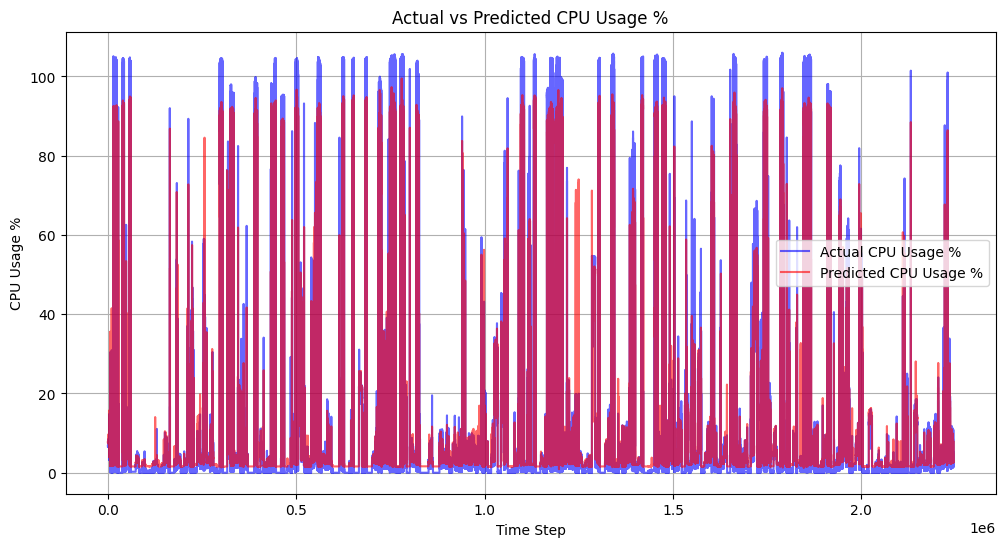

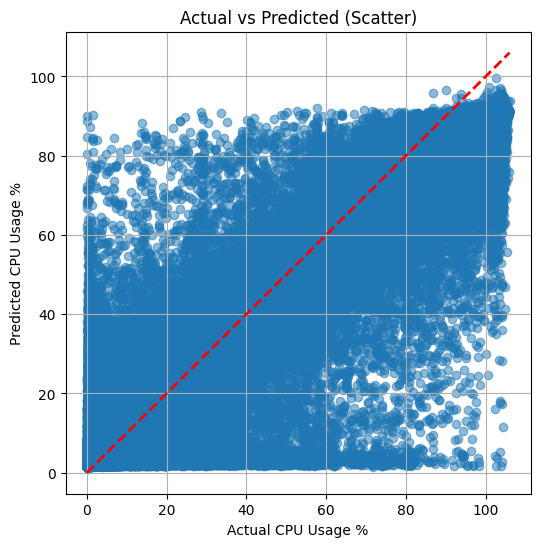

Predictions saved to 'predictions.csv'
Trained model saved to 'trained_lstm_model.pth'
Scaler saved to 'scaler.pkl'
Files found: ['scaler.pkl', 'main.ipynb', 'Untitled.ipynb', '.ipynb_checkpoints', 'checkpoint.pth', 'trained_lstm_model.pth', 'fastStorage', 'predictions.csv']
CUDA available: True
Current device: 0


In [6]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
from concurrent.futures import ThreadPoolExecutor
from torch.cuda.amp import GradScaler, autocast
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib  # Added for saving the scaler

# Function to load individual CSV files
def load_data(file_path):
    try:
        df = pd.read_csv(file_path, delimiter=';\t', engine='python', header=None, skiprows=1)
        df.columns = ['Timestamp', 'CPU Cores', 'CPU Capacity Provisioned', 'CPU Usage MHz', 'CPU Usage %',
                      'Memory Provisioned KB', 'Memory Usage KB', 'Disk Read KB/s', 'Disk Write KB/s',
                      'Network Received KB/s', 'Network Transmitted KB/s']
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='ms', errors='coerce')
        df.set_index('Timestamp', inplace=True)
        return df
    except Exception as e:
        print(f"Error loading file {file_path}: {e}")
        return None

# Function to load all CSV data from a directory using parallel processing
def load_all_data(directory):
    all_files = glob.glob(os.path.join(directory, "*.csv"))
    if not all_files:
        raise ValueError(f"No CSV files found in directory: {directory}")
    
    with ThreadPoolExecutor() as executor:
        data_list = list(executor.map(load_data, all_files))
    
    data_list = [df for df in data_list if df is not None]
    return pd.concat(data_list, axis=0) if data_list else None

# Data preparation function
def prepare_data(df, feature_columns, target_column, time_steps=20):
    scaler = MinMaxScaler()
    df_scaled = scaler.fit_transform(df[feature_columns + [target_column]])

    X, y = [], []
    for i in range(len(df_scaled) - time_steps):
        X.append(df_scaled[i:i+time_steps, :-1])
        y.append(df_scaled[i+time_steps, -1])

    X = torch.FloatTensor(np.array(X))
    y = torch.FloatTensor(np.array(y)).unsqueeze(-1)
    return X, y, scaler

# LSTM model class for PyTorch
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size1=100, hidden_size2=100, hidden_size3=50, dropout_rate=0.3):
        super(LSTMModel, self).__init__()
        self.lstm1 = nn.LSTM(input_size, hidden_size1, batch_first=True)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.lstm2 = nn.LSTM(hidden_size1, hidden_size2, batch_first=True)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.lstm3 = nn.LSTM(hidden_size2, hidden_size3, batch_first=True)
        self.dropout3 = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(hidden_size3, 50)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(50, 25)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(25, 1)

    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.dropout1(x)
        x, _ = self.lstm2(x)
        x = self.dropout2(x)
        x, _ = self.lstm3(x)
        x = self.dropout3(x)
        x = self.fc1(x[:, -1, :])  # Take the last time step
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

# Function to save checkpoint
def save_checkpoint(model, optimizer, epoch, loss, checkpoint_path='checkpoint.pth'):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }, checkpoint_path)
    print(f"Checkpoint saved at epoch {epoch}")

# Function to load checkpoint
def load_checkpoint(model, optimizer, checkpoint_path='checkpoint.pth'):
    if os.path.isfile(checkpoint_path):
        checkpoint = torch.load(checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1  # Resume from next epoch
        loss = checkpoint['loss']
        print(f"Checkpoint loaded, resuming from epoch {start_epoch}")
        return start_epoch, loss
    else:
        print("No checkpoint found, starting from scratch")
        return 0, None

# Function to inverse transform predictions and actual values
def inverse_transform_predictions(predictions, actuals, scaler, target_idx):
    dummy = np.zeros((len(predictions), scaler.n_features_in_))
    dummy[:, target_idx] = predictions.flatten()  # Fill target column with predictions
    pred_original = scaler.inverse_transform(dummy)[:, target_idx]
    
    dummy[:, target_idx] = actuals.flatten()  # Fill target column with actuals
    actual_original = scaler.inverse_transform(dummy)[:, target_idx]
    
    return pred_original, actual_original

# Evaluation and visualization function
def evaluate_and_visualize(model, test_loader, y_test, scaler, feature_columns, target_column, device):
    model.eval()
    predictions = []
    actuals = y_test.cpu().numpy()  # Convert actuals to numpy

    # Generate predictions
    with torch.no_grad():
        for batch_X, _ in test_loader:
            batch_X = batch_X.to(device)
            with autocast():
                batch_pred = model(batch_X)
            predictions.append(batch_pred.cpu())
    predictions = torch.cat(predictions, dim=0).numpy()

    # Get the index of the target column in the original feature set
    target_idx = len(feature_columns)  # Target column is appended last in prepare_data

    # Inverse transform to original scale
    pred_original, actual_original = inverse_transform_predictions(predictions, actuals, scaler, target_idx)

    # Calculate evaluation metrics
    mse = mean_squared_error(actual_original, pred_original)
    mae = mean_absolute_error(actual_original, pred_original)
    r2 = r2_score(actual_original, pred_original)

    print("\nEvaluation Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")

    # Visualization: Plot actual vs predicted
    plt.figure(figsize=(12, 6))
    plt.plot(actual_original, label="Actual CPU Usage %", color="blue", alpha=0.6)
    plt.plot(pred_original, label="Predicted CPU Usage %", color="red", alpha=0.6)
    plt.title("Actual vs Predicted CPU Usage %")
    plt.xlabel("Time Step")
    plt.ylabel("CPU Usage %")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Scatter plot for correlation
    plt.figure(figsize=(6, 6))
    plt.scatter(actual_original, pred_original, alpha=0.5)
    plt.plot([min(actual_original), max(actual_original)], [min(actual_original), max(actual_original)], 'r--', lw=2)
    plt.title("Actual vs Predicted (Scatter)")
    plt.xlabel("Actual CPU Usage %")
    plt.ylabel("Predicted CPU Usage %")
    plt.grid(True)
    plt.show()

    # Save predictions to CSV
    results_df = pd.DataFrame({
        "Actual": actual_original,
        "Predicted": pred_original
    })
    results_df.to_csv("predictions.csv", index=False)
    print("Predictions saved to 'predictions.csv'")

# Main execution
def main():
    data_directory = "./fastStorage/2013-8"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    checkpoint_path = 'checkpoint.pth'
    
    # Check if directory exists
    if not os.path.exists(data_directory):
        print(f"Directory not found: {data_directory}")
        return
    
    print("Loading data...")
    df = load_all_data(data_directory)
    
    if df is None or df.empty:
        print("No valid data found. Exiting.")
        return
    
    print("Data loaded successfully. Preparing dataset...")
    
    feature_columns = ['CPU Cores', 'CPU Capacity Provisioned', 'CPU Usage MHz', 'Memory Provisioned KB',
                       'Memory Usage KB', 'Disk Read KB/s', 'Disk Write KB/s', 'Network Received KB/s',
                       'Network Transmitted KB/s']
    target_column = 'CPU Usage %'

    X, y, scaler = prepare_data(df, feature_columns, target_column)
    
    # Split data
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    print(f"Training data: {X_train.shape}, Testing data: {X_test.shape}")

    # Create DataLoader for training and testing
    batch_size = 512
    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)

    # Initialize model
    model = LSTMModel(input_size=X_train.shape[2]).to(device)
    optimizer = optim.Adam(model.parameters())
    criterion = nn.MSELoss()
    scaler_grad = GradScaler()  # Renamed to avoid conflict with 'scaler'

    # Load checkpoint if exists
    start_epoch, _ = load_checkpoint(model, optimizer, checkpoint_path)
    
    print("Training LSTM model...")
    num_epochs = 50
    
    try:
        for epoch in range(start_epoch, num_epochs):
            model.train()
            total_loss = 0
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                optimizer.zero_grad()
                with autocast():
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                scaler_grad.scale(loss).backward()
                scaler_grad.step(optimizer)
                scaler_grad.update()
                total_loss += loss.item()
            
            avg_train_loss = total_loss / len(train_loader)
            
            # Validation
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for batch_X, batch_y in test_loader:
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    with autocast():
                        val_outputs = model(batch_X)
                        val_loss += criterion(val_outputs, batch_y).item()
            
            avg_val_loss = val_loss / len(test_loader)
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
            
            # Save checkpoint after each epoch
            save_checkpoint(model, optimizer, epoch, avg_train_loss, checkpoint_path)
    
    except KeyboardInterrupt:
        print("Training interrupted. Saving checkpoint...")
        save_checkpoint(model, optimizer, epoch, avg_train_loss, checkpoint_path)
        print("Checkpoint saved. Exiting.")

    # Predictions
    model.eval()
    with torch.no_grad():
        predictions = []
        for batch_X, _ in test_loader:
            batch_X = batch_X.to(device)
            with autocast():
                batch_pred = model(batch_X)
            predictions.append(batch_pred.cpu())
        predictions = torch.cat(predictions, dim=0)
    
    print("Model training complete. Predictions generated.")
    
    # Evaluate and visualize
    print("Evaluating and visualizing results...")
    evaluate_and_visualize(model, test_loader, y_test, scaler, feature_columns, target_column, device)

    # Save the trained model's state_dict
    model_path = 'trained_lstm_model.pth'
    try:
        torch.save(model.state_dict(), model_path)
        print(f"Trained model saved to '{model_path}'")
    except Exception as e:
        print(f"Error saving model: {e}")

    # Save the scaler
    scaler_path = 'scaler.pkl'
    try:
        joblib.dump(scaler, scaler_path)
        print(f"Scaler saved to '{scaler_path}'")
    except Exception as e:
        print(f"Error saving scaler: {e}")

# Run the script
if __name__ == "__main__":
    main()

# Check available files and GPU status
print("Files found:", os.listdir("./"))
print("CUDA available:", torch.cuda.is_available())
print("Current device:", torch.cuda.current_device() if torch.cuda.is_available() else "CPU")

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
from concurrent.futures import ThreadPoolExecutor
from torch.cuda.amp import autocast  # Import autocast directly
from torch.amp import GradScaler  # Updated import for GradScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Function to load individual CSV files
def load_data(file_path):
    try:
        df = pd.read_csv(file_path, delimiter=';\t', engine='python', header=None, skiprows=1)
        df.columns = ['Timestamp', 'CPU Cores', 'CPU Capacity Provisioned', 'CPU Usage MHz', 'CPU Usage %',
                      'Memory Provisioned KB', 'Memory Usage KB', 'Disk Read KB/s', 'Disk Write KB/s',
                      'Network Received KB/s', 'Network Transmitted KB/s']
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='ms', errors='coerce')
        df.set_index('Timestamp', inplace=True)
        return df
    except Exception as e:
        print(f"Error loading file {file_path}: {e}")
        return None

# Function to load all CSV data from a directory using parallel processing
def load_all_data(directory):
    all_files = glob.glob(os.path.join(directory, "*.csv"))
    if not all_files:
        raise ValueError(f"No CSV files found in directory: {directory}")
    
    with ThreadPoolExecutor() as executor:
        data_list = list(executor.map(load_data, all_files))
    
    data_list = [df for df in data_list if df is not None]
    return pd.concat(data_list, axis=0) if data_list else None

# Data preparation function (modified for multivariate output)
def prepare_data(df, feature_columns, time_steps=20):
    scaler = MinMaxScaler()
    df_scaled = scaler.fit_transform(df[feature_columns])

    X, y = [], []
    for i in range(len(df_scaled) - time_steps):
        X.append(df_scaled[i:i+time_steps, :])  # All features as input
        y.append(df_scaled[i+time_steps, :])    # All features as output

    X = torch.FloatTensor(np.array(X))
    y = torch.FloatTensor(np.array(y))
    return X, y, scaler

# LSTM model class for multivariate output
class LSTMModel(nn.Module):
    def __init__(self, input_size, output_size, hidden_size1=100, hidden_size2=100, hidden_size3=50, dropout_rate=0.3):
        super(LSTMModel, self).__init__()
        self.lstm1 = nn.LSTM(input_size, hidden_size1, batch_first=True)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.lstm2 = nn.LSTM(hidden_size1, hidden_size2, batch_first=True)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.lstm3 = nn.LSTM(hidden_size2, hidden_size3, batch_first=True)
        self.dropout3 = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(hidden_size3, 50)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(50, 25)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(25, output_size)  # Output size matches number of features

    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.dropout1(x)
        x, _ = self.lstm2(x)
        x = self.dropout2(x)
        x, _ = self.lstm3(x)
        x = self.dropout3(x)
        x = self.fc1(x[:, -1, :])  # Take the last time step
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

# Function to save checkpoint
def save_checkpoint(model, optimizer, epoch, loss, checkpoint_path='checkpoint.pth'):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }, checkpoint_path)
    print(f"Checkpoint saved at epoch {epoch}")

# Function to load checkpoint
def load_checkpoint(model, optimizer, checkpoint_path='checkpoint.pth'):
    if os.path.isfile(checkpoint_path):
        checkpoint = torch.load(checkpoint_path)
        try:
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            start_epoch = checkpoint['epoch'] + 1
            loss = checkpoint['loss']
            print(f"Checkpoint loaded, resuming from epoch {start_epoch}")
            return start_epoch, loss
        except RuntimeError as e:
            print(f"Checkpoint incompatible with current model architecture: {e}")
            print("Starting training from scratch.")
            return 0, None
    else:
        print("No checkpoint found, starting from scratch")
        return 0, None

# Function to inverse transform predictions and actual values
def inverse_transform_predictions(predictions, actuals, scaler):
    pred_original = scaler.inverse_transform(predictions)
    actual_original = scaler.inverse_transform(actuals)
    return pred_original, actual_original

# Evaluation and visualization function (modified for all features)
def evaluate_and_visualize(model, test_loader, y_test, scaler, feature_columns, device):
    model.eval()
    predictions = []
    actuals = y_test.cpu().numpy()

    # Generate predictions
    with torch.no_grad():
        for batch_X, _ in test_loader:
            batch_X = batch_X.to(device)
            with autocast():
                batch_pred = model(batch_X)
            predictions.append(batch_pred.cpu())
    predictions = torch.cat(predictions, dim=0).numpy()

    # Inverse transform to original scale
    pred_original, actual_original = inverse_transform_predictions(predictions, actuals, scaler)

    # Calculate evaluation metrics for each feature
    print("\nEvaluation Metrics for Each Feature:")
    for i, feature in enumerate(feature_columns):
        mse = mean_squared_error(actual_original[:, i], pred_original[:, i])
        mae = mean_absolute_error(actual_original[:, i], pred_original[:, i])
        r2 = r2_score(actual_original[:, i], pred_original[:, i])
        print(f"{feature}:")
        print(f"  Mean Squared Error (MSE): {mse:.4f}")
        print(f"  Mean Absolute Error (MAE): {mae:.4f}")
        print(f"  R² Score: {r2:.4f}")

    # Visualization: Plot actual vs predicted for each feature
    num_features = len(feature_columns)
    fig, axes = plt.subplots(num_features, 1, figsize=(12, 4 * num_features), sharex=True)
    if num_features == 1:
        axes = [axes]  # Ensure axes is iterable for single feature case
    
    for i, (feature, ax) in enumerate(zip(feature_columns, axes)):
        ax.plot(actual_original[:, i], label=f"Actual {feature}", color="blue", alpha=0.6)
        ax.plot(pred_original[:, i], label=f"Predicted {feature}", color="red", alpha=0.6)
        ax.set_title(f"Actual vs Predicted {feature}")
        ax.set_ylabel(feature)
        ax.legend()
        ax.grid(True)
    
    axes[-1].set_xlabel("Time Step")
    plt.tight_layout()
    plt.show()

    # Scatter plots for each feature
    fig, axes = plt.subplots(num_features // 2 + num_features % 2, 2, figsize=(12, 4 * (num_features // 2 + num_features % 2)))
    axes = axes.flatten()  # Flatten for easier indexing
    
    for i, feature in enumerate(feature_columns):
        axes[i].scatter(actual_original[:, i], pred_original[:, i], alpha=0.5)
        min_val, max_val = min(actual_original[:, i]), max(actual_original[:, i])
        axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
        axes[i].set_title(f"Actual vs Predicted {feature} (Scatter)")
        axes[i].set_xlabel(f"Actual {feature}")
        axes[i].set_ylabel(f"Predicted {feature}")
        axes[i].grid(True)
    
    # Hide unused subplots if any
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

    # Save predictions to CSV
    results_df = pd.DataFrame(pred_original, columns=[f"Predicted_{col}" for col in feature_columns])
    results_df = pd.concat([results_df, pd.DataFrame(actual_original, columns=[f"Actual_{col}" for col in feature_columns])], axis=1)
    results_df.to_csv("predictions_all_features.csv", index=False)
    print("Predictions saved to 'predictions_all_features.csv'")

# Main execution
def main():
    data_directory = "./fastStorage/2013-8"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    checkpoint_path = 'checkpoint.pth'
    
    if not os.path.exists(data_directory):
        print(f"Directory not found: {data_directory}")
        return
    
    print("Loading data...")
    df = load_all_data(data_directory)
    
    if df is None or df.empty:
        print("No valid data found. Exiting.")
        return
    
    print("Data loaded successfully. Preparing dataset...")
    
    feature_columns = ['CPU Cores', 'CPU Capacity Provisioned', 'CPU Usage MHz', 'CPU Usage %',
                       'Memory Provisioned KB', 'Memory Usage KB', 'Disk Read KB/s', 'Disk Write KB/s',
                       'Network Received KB/s', 'Network Transmitted KB/s']

    X, y, scaler = prepare_data(df, feature_columns)
    
    # Split data
    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    print(f"Training data: {X_train.shape}, Testing data: {X_test.shape}")

    # Create DataLoader for training and testing
    batch_size = 512
    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)

    # Initialize model (input_size and output_size both match number of features)
    model = LSTMModel(input_size=len(feature_columns), output_size=len(feature_columns)).to(device)
    optimizer = optim.Adam(model.parameters())
    criterion = nn.MSELoss()
    scaler_grad = GradScaler('cuda') if torch.cuda.is_available() else GradScaler('cpu')  # Updated GradScaler

    # Load checkpoint if exists
    start_epoch, _ = load_checkpoint(model, optimizer, checkpoint_path)
    
    print("Training LSTM model...")
    num_epochs = 50
    
    try:
        for epoch in range(start_epoch, num_epochs):
            model.train()
            total_loss = 0
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                optimizer.zero_grad()
                with autocast():
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                scaler_grad.scale(loss).backward()
                scaler_grad.step(optimizer)
                scaler_grad.update()
                total_loss += loss.item()
            
            avg_train_loss = total_loss / len(train_loader)
            
            # Validation
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for batch_X, batch_y in test_loader:
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    with autocast():
                        val_outputs = model(batch_X)
                        val_loss += criterion(val_outputs, batch_y).item()
            
            avg_val_loss = val_loss / len(test_loader)
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
            
            # Save checkpoint after each epoch
            save_checkpoint(model, optimizer, epoch, avg_train_loss, checkpoint_path)
    
    except KeyboardInterrupt:
        print("Training interrupted. Saving checkpoint...")
        save_checkpoint(model, optimizer, epoch, avg_train_loss, checkpoint_path)
        print("Checkpoint saved. Exiting.")

    # Predictions
    model.eval()
    with torch.no_grad():
        predictions = []
        for batch_X, _ in test_loader:
            batch_X = batch_X.to(device)
            with autocast():
                batch_pred = model(batch_X)
            predictions.append(batch_pred.cpu())
        predictions = torch.cat(predictions, dim=0)
    
    print("Model training complete. Predictions generated.")
    
    # Evaluate and visualize
    print("Evaluating and visualizing results...")
    evaluate_and_visualize(model, test_loader, y_test, scaler, feature_columns, device)

    # Save the trained model's state_dict
    model_path = 'trained_lstm_model_all_features.pth'
    try:
        torch.save(model.state_dict(), model_path)
        print(f"Trained model saved to '{model_path}'")
    except Exception as e:
        print(f"Error saving model: {e}")

    # Save the scaler
    scaler_path = 'scaler_all_features.pkl'
    try:
        joblib.dump(scaler, scaler_path)
        print(f"Scaler saved to '{scaler_path}'")
    except Exception as e:
        print(f"Error saving scaler: {e}")

# Run the script
if __name__ == "__main__":
    main()

# Check available files and GPU status
print("Files found:", os.listdir("./"))
print("CUDA available:", torch.cuda.is_available())
print("Current device:", torch.cuda.current_device() if torch.cuda.is_available() else "CPU")

Loading data...
Data loaded successfully. Preparing dataset...
Training data: torch.Size([8977424, 20, 10]), Testing data: torch.Size([2244356, 20, 10])
Checkpoint loaded, resuming from epoch 3
Training LSTM model...


/tmp/ipykernel_1420903/1111681469.py:254: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_1420903/1111681469.py:270: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [4/50], Loss: 0.0001, Val Loss: 0.0003
Checkpoint saved at epoch 3
Training interrupted. Saving checkpoint...
Checkpoint saved at epoch 4
Checkpoint saved. Exiting.


/tmp/ipykernel_1420903/1111681469.py:291: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Model training complete. Predictions generated.
Evaluating and visualizing results...


/tmp/ipykernel_1420903/1111681469.py:132: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/home/jupyter-228w1a4216/.local/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:582: RuntimeWarning: overflow encountered in divide
  X /= self.scale_



Evaluation Metrics for Each Feature:
CPU Cores:
  Mean Squared Error (MSE): 0.9948
  Mean Absolute Error (MAE): 0.8267
  R² Score: 0.9419


ValueError: Input contains infinity or a value too large for dtype('float32').